In [17]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [18]:
dataset, info = tfds.load(
    'tiny_shakespeare',
    with_info=True,
    as_supervised=False
)
print(info)

tfds.core.DatasetInfo(
    name='tiny_shakespeare',
    full_name='tiny_shakespeare/1.0.0',
    description="""
    40,000 lines of Shakespeare from a variety of Shakespeare's plays. Featured in
    Andrej Karpathy's blog post 'The Unreasonable Effectiveness of Recurrent Neural
    Networks': http://karpathy.github.io/2015/05/21/rnn-effectiveness/.
    
    To use for e.g. character modelling:
    
    ```
    d = tfds.load(name='tiny_shakespeare')['train']
    d = d.map(lambda x: tf.strings.unicode_split(x['text'], 'UTF-8'))
    # train split includes vocabulary for other splits
    vocabulary = sorted(set(next(iter(d)).numpy()))
    d = d.map(lambda x: {'cur_char': x[:-1], 'next_char': x[1:]})
    d = d.unbatch()
    seq_len = 100
    batch_size = 2
    d = d.batch(seq_len)
    d = d.batch(batch_size)
    ```
    """,
    homepage='https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt',
    data_dir='C:\\Users\\BEST\\tensorflow_datasets\\tiny_shakespeare\\1.

In [19]:
## Text Extract

train_data = dataset['train']

sample = next(iter(train_data))
text =sample['text'].numpy().decode('utf-8')

print(text[:1000])


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [20]:
## basic preprocessing

text = text.lower()

print(text[:1000])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for the gods know i
speak this in hunger for bread, not in thirst for revenge.



In [21]:
## Tokenization

tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts([text])


In [22]:
## Text - Number Sequence
sequences = tokenizer.texts_to_sequences([text])

print(sequences[0][:50])
      

[87, 248, 143, 34, 962, 145, 609, 127, 16, 106, 35, 106, 106, 87, 248, 7, 41, 35, 1228, 351, 3, 192, 65, 3, 3678, 35, 1228, 1228, 87, 248, 87, 7, 92, 1052, 214, 11, 2085, 544, 3, 1, 281, 35, 34, 2333, 34, 2333, 87, 248, 67, 78]


In [23]:
sequence_length = 20

input_sequences = []

token_list = sequences[0]

for i in range(1, len(token_list)):
    start = max(0, i - sequence_length)
    n_gram_sequence = token_list[start:i+1]
    input_sequences.append(n_gram_sequence)

padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    input_sequences,
    maxlen=sequence_length + 1,
    padding='pre'
)

X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (183772, 20)
y shape: (183772,)


In [24]:
## Build LSTM Model

total_words = len(tokenizer.word_index) + 1

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=total_words,
        output_dim=100,
        input_shape=(20,)
    ),
    tf.keras.layers.LSTM(150),
    tf.keras.layers.Dense(
        total_words,
        activation='softmax'
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 20, 100)             │       1,191,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 150)                 │         150,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11914)               │       1,799,014 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,141,014 (11.98 MB)

 Trainable params: 3,141,014 (11.98 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
## Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
## Train the model

history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
2585/2585 ━━━━━━━━━━━━━━━━━━━━ 211s 80ms/step - accuracy: 0.0440 - loss: 6.7424 - val_accuracy: 0.0629 - val_loss: 6.6005
Epoch 2/5
2585/2585 ━━━━━━━━━━━━━━━━━━━━ 211s 81ms/step - accuracy: 0.0814 - loss: 6.1600 - val_accuracy: 0.0826 - val_loss: 6.4896
Epoch 3/5
2585/2585 ━━━━━━━━━━━━━━━━━━━━ 212s 82ms/step - accuracy: 0.0959 - loss: 5.8272 - val_accuracy: 0.0881 - val_loss: 6.4913
Epoch 4/5
2585/2585 ━━━━━━━━━━━━━━━━━━━━ 210s 81ms/step - accuracy: 0.1076 - loss: 5.5496 - val_accuracy: 0.0923 - val_loss: 6.5459
Epoch 5/5
2585/2585 ━━━━━━━━━━━━━━━━━━━━ 209s 81ms/step - accuracy: 0.1182 - loss: 5.2834 - val_accuracy: 0.0928 - val_loss: 6.6278


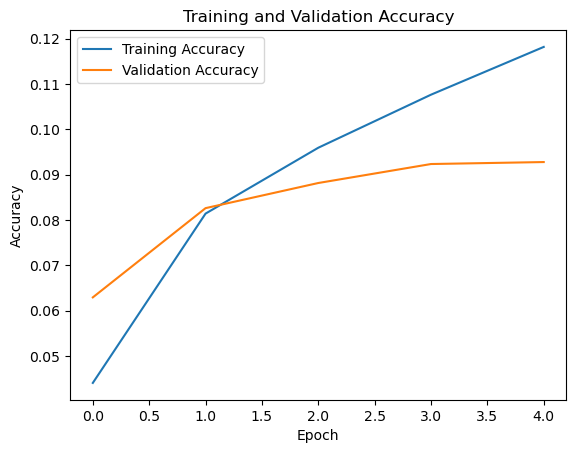

In [27]:
## Training result plot

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

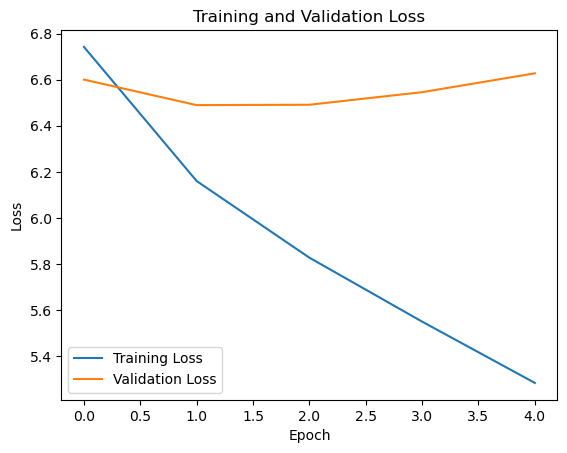

In [28]:
## loss graph

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [29]:
## prediction function

def predict_next_word(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    token_list = token_list[-20:]
    
    token_list = tf.keras.preprocessing.sequence.pad_sequences(
        [token_list],
        maxlen=20,
        padding='pre'
    )
    
    predicted_probs = model.predict(token_list, verbose=0)
    
    predicted_id = np.argmax(predicted_probs, axis=-1)[0]
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_id:
            return word

In [30]:
## Test 1

seed_text = "to be"

next_word = predict_next_word(seed_text)

print("Input:", seed_text)
print("Predicted next word:", next_word)

Input: to be
Predicted next word: a


In [31]:
# Test 5 examples

test_sentences = [
    "to be",
    "my lord",
    "good night",
    "i love",
    "what is"
]

for sentence in test_sentences:
    prediction = predict_next_word(sentence)
    print(f"{sentence} → {prediction}")

to be → a
my lord → i
good night → i
i love → not
what is → not
